# 姿態辨識模型比較

比較不同的姿態估計模型在功夫動作辨識任務上的表現：

## 比較的模型

### YOLO Pose 系列
| 模型 | 版本 | 大小 | 特點 |
|------|------|------|------|
| YOLOv8n-pose | v8 | Nano | 輕量、快速 |
| YOLOv8s-pose | v8 | Small | 平衡速度與精度 |
| YOLOv8m-pose | v8 | Medium | 較高精度 |
| YOLO11n-pose | v11 | Nano | 最新版本、輕量 |
| YOLO11s-pose | v11 | Small | 最新版本、平衡 |
| YOLO11m-pose | v11 | Medium | 最新版本、高精度 |

### MediaPipe Pose
| 模型 | 特點 |
|------|------|
| MediaPipe Pose | Google 開發，輕量快速，33個關鍵點 |

## 比較指標
- 推理速度 (FPS)
- 關鍵點偵測穩定性
- 模型大小
- 記憶體使用量

## 1. 匯入套件

In [2]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
from pathlib import Path

# YOLO
from ultralytics import YOLO

# MediaPipe
import mediapipe as mp

# 設定中文字體
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'SimHei', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

print("套件載入完成")

套件載入完成


## 2. 定義姿態模型包裝類別

In [3]:
class YOLOPoseModel:
    """YOLO Pose 模型包裝"""
    
    # YOLO 關鍵點對應 (17 點)
    KEYPOINT_NAMES = [
        'nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear',
        'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
        'left_wrist', 'right_wrist', 'left_hip', 'right_hip',
        'left_knee', 'right_knee', 'left_ankle', 'right_ankle'
    ]
    
    def __init__(self, model_name: str):
        """
        初始化 YOLO Pose 模型
        
        model_name: 'yolov8n-pose', 'yolov8s-pose', 'yolov8m-pose', 'yolov8l-pose'
                    或本地模型路徑
        """
        self.model_name = model_name
        self.model = YOLO(model_name)
        self.num_keypoints = 17
        
    def predict(self, image):
        """
        預測圖片中的人體姿態
        
        回傳:
            keypoints: (17, 2) 正規化座標
            confidences: (17,) 置信度
            inference_time: 推理時間 (ms)
        """
        start_time = time.time()
        results = self.model.predict(image, verbose=False)
        inference_time = (time.time() - start_time) * 1000
        
        if len(results[0]) == 0:
            return None, None, inference_time
        
        # 取得第一個人的關鍵點
        keypoints_xy = results[0][0].keypoints.xyn[0].cpu().numpy()  # 正規化座標
        keypoints_conf = results[0][0].keypoints.conf[0].cpu().numpy()
        
        return keypoints_xy, keypoints_conf, inference_time
    
    def get_annotated_frame(self, image):
        """取得繪製骨架的圖片"""
        results = self.model.predict(image, verbose=False)
        if len(results[0]) > 0:
            return results[0].plot()
        return image.copy()


class MediaPipePoseModel:
    """MediaPipe Pose 模型包裝"""
    
    # MediaPipe 關鍵點對應 (33 點，取前 17 點對應 YOLO)
    # 對應關係：MediaPipe index -> YOLO index
    MP_TO_YOLO_MAPPING = {
        0: 0,   # nose
        2: 1,   # left_eye (inner) -> left_eye
        5: 2,   # right_eye (inner) -> right_eye
        7: 3,   # left_ear
        8: 4,   # right_ear
        11: 5,  # left_shoulder
        12: 6,  # right_shoulder
        13: 7,  # left_elbow
        14: 8,  # right_elbow
        15: 9,  # left_wrist
        16: 10, # right_wrist
        23: 11, # left_hip
        24: 12, # right_hip
        25: 13, # left_knee
        26: 14, # right_knee
        27: 15, # left_ankle
        28: 16, # right_ankle
    }
    
    def __init__(self, model_complexity: int = 1):
        """
        初始化 MediaPipe Pose
        
        model_complexity: 0 (輕量), 1 (標準), 2 (精確)
        """
        self.model_name = f"MediaPipe Pose (complexity={model_complexity})"
        self.mp_pose = mp.solutions.pose
        self.mp_drawing = mp.solutions.drawing_utils
        self.pose = self.mp_pose.Pose(
            static_image_mode=True,
            model_complexity=model_complexity,
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5
        )
        self.num_keypoints = 17  # 轉換為與 YOLO 相同的 17 點
        
    def predict(self, image):
        """
        預測圖片中的人體姿態
        
        回傳:
            keypoints: (17, 2) 正規化座標 (與 YOLO 格式相同)
            confidences: (17,) 置信度
            inference_time: 推理時間 (ms)
        """
        # 轉換 BGR -> RGB
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        start_time = time.time()
        results = self.pose.process(image_rgb)
        inference_time = (time.time() - start_time) * 1000
        
        if results.pose_landmarks is None:
            return None, None, inference_time
        
        # 轉換為 YOLO 格式的 17 個關鍵點
        keypoints = np.zeros((17, 2))
        confidences = np.zeros(17)
        
        landmarks = results.pose_landmarks.landmark
        for mp_idx, yolo_idx in self.MP_TO_YOLO_MAPPING.items():
            keypoints[yolo_idx] = [landmarks[mp_idx].x, landmarks[mp_idx].y]
            confidences[yolo_idx] = landmarks[mp_idx].visibility
        
        return keypoints, confidences, inference_time
    
    def get_annotated_frame(self, image):
        """取得繪製骨架的圖片"""
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        results = self.pose.process(image_rgb)
        
        annotated = image.copy()
        if results.pose_landmarks:
            self.mp_drawing.draw_landmarks(
                annotated,
                results.pose_landmarks,
                self.mp_pose.POSE_CONNECTIONS
            )
        return annotated
    
    def close(self):
        """釋放資源"""
        self.pose.close()


print("模型類別定義完成")

模型類別定義完成


## 3. 載入測試圖片

In [4]:
# 從 dataset 資料夾載入測試圖片
dataset_path = Path('./dataset')

# 收集所有動作圖片 (使用 analyzed_ 前綴)
test_images = []
for pattern in ['analyzed_act1_*.jpg', 'analyzed_act2_*.jpg', 'analyzed_act3_*.jpg', 'analyzed_act4_*.jpg']:
    test_images.extend(list(dataset_path.glob(pattern)))

# 隨機抽樣測試 (最多 50 張)
np.random.seed(42)
if len(test_images) > 50:
    test_images = list(np.random.choice(test_images, 50, replace=False))

print(f"找到 {len(test_images)} 張測試圖片")
print(f"\n範例圖片:")
for img in test_images[:5]:
    print(f"  - {img.name}")

找到 50 張測試圖片

範例圖片:
  - analyzed_act3_kick_p2_27.jpg
  - analyzed_act2_punch_p2_24.jpg
  - analyzed_act2_punch_p1_7.jpg
  - analyzed_act1_fist_p1_31.jpg
  - analyzed_act1_fist_p1_18.jpg


## 4. 初始化所有模型

In [5]:
print("正在載入模型...\n")

models = {}

# YOLOv8 Pose 模型
yolov8_models = [
    ('YOLOv8n-pose', 'yolov8n-pose.pt'),
    ('YOLOv8s-pose', 'yolov8s-pose.pt'),
    ('YOLOv8m-pose', 'yolov8m-pose.pt'),
]

# YOLO11 Pose 模型 (最新版本)
yolo11_models = [
    ('YOLO11n-pose', 'yolo11n-pose.pt'),
    ('YOLO11s-pose', 'yolo11s-pose.pt'),
    ('YOLO11m-pose', 'yolo11m-pose.pt'),
]

# 載入 YOLOv8 模型
print("=== YOLOv8 系列 ===")
for name, model_path in yolov8_models:
    try:
        print(f"載入 {name}...")
        models[name] = YOLOPoseModel(model_path)
        print(f"  ✓ {name} 載入成功")
    except Exception as e:
        print(f"  ✗ {name} 載入失敗: {e}")

# 載入 YOLO11 模型
print("\n=== YOLO11 系列 (最新) ===")
for name, model_path in yolo11_models:
    try:
        print(f"載入 {name}...")
        models[name] = YOLOPoseModel(model_path)
        print(f"  ✓ {name} 載入成功")
    except Exception as e:
        print(f"  ✗ {name} 載入失敗: {e}")

# 本地 YOLO 模型 (如果存在)
print("\n=== 本地模型 ===")
local_model = Path('./model/pose_model.pt')
if local_model.exists():
    try:
        print(f"載入本地模型 pose_model.pt...")
        models['Local YOLO Pose'] = YOLOPoseModel(str(local_model))
        print(f"  ✓ Local YOLO Pose 載入成功")
    except Exception as e:
        print(f"  ✗ 載入失敗: {e}")

# MediaPipe Pose
print("\n=== MediaPipe 系列 ===")
mediapipe_configs = [
    ('MediaPipe Lite', 0),
    ('MediaPipe Full', 1),
    ('MediaPipe Heavy', 2),
]

for name, complexity in mediapipe_configs:
    try:
        print(f"載入 {name}...")
        models[name] = MediaPipePoseModel(model_complexity=complexity)
        print(f"  ✓ {name} 載入成功")
    except Exception as e:
        print(f"  ✗ {name} 載入失敗: {e}")

print(f"\n{'='*50}")
print(f"成功載入 {len(models)} 個模型")
print(f"{'='*50}")

正在載入模型...

=== YOLOv8 系列 ===
載入 YOLOv8n-pose...
  ✓ YOLOv8n-pose 載入成功
載入 YOLOv8s-pose...
  ✓ YOLOv8s-pose 載入成功
載入 YOLOv8m-pose...
  ✓ YOLOv8m-pose 載入成功

=== YOLO11 系列 (最新) ===
載入 YOLO11n-pose...
  ✓ YOLO11n-pose 載入成功
載入 YOLO11s-pose...
  ✓ YOLO11s-pose 載入成功
載入 YOLO11m-pose...
  ✓ YOLO11m-pose 載入成功

=== 本地模型 ===
載入本地模型 pose_model.pt...
  ✓ Local YOLO Pose 載入成功

=== MediaPipe 系列 ===
載入 MediaPipe Lite...
  ✓ MediaPipe Lite 載入成功
載入 MediaPipe Full...
  ✓ MediaPipe Full 載入成功
載入 MediaPipe Heavy...
  ✓ MediaPipe Heavy 載入成功

成功載入 10 個模型


## 5. 執行基準測試

In [6]:
def run_benchmark(models, test_images, num_warmup=3):
    """
    執行基準測試
    
    回傳:
        results: 各模型的測試結果
    """
    results = {name: {
        'inference_times': [],
        'detection_count': 0,
        'total_count': 0,
        'keypoint_confidences': [],
    } for name in models}
    
    # Warmup (讓模型預熱)
    print("模型預熱中...")
    warmup_img = cv2.imread(str(test_images[0]))
    for name, model in models.items():
        for _ in range(num_warmup):
            model.predict(warmup_img)
    print("預熱完成\n")
    
    # 測試每張圖片
    print(f"開始測試 {len(test_images)} 張圖片...")
    
    for i, img_path in enumerate(test_images):
        image = cv2.imread(str(img_path))
        if image is None:
            continue
        
        for name, model in models.items():
            keypoints, confidences, inference_time = model.predict(image)
            
            results[name]['inference_times'].append(inference_time)
            results[name]['total_count'] += 1
            
            if keypoints is not None:
                results[name]['detection_count'] += 1
                results[name]['keypoint_confidences'].append(confidences.mean())
        
        if (i + 1) % 10 == 0:
            print(f"  已處理 {i + 1}/{len(test_images)} 張圖片")
    
    print("測試完成！\n")
    return results


# 執行測試
benchmark_results = run_benchmark(models, test_images)

模型預熱中...
預熱完成

開始測試 50 張圖片...
  已處理 10/50 張圖片
  已處理 20/50 張圖片
  已處理 30/50 張圖片
  已處理 40/50 張圖片
  已處理 50/50 張圖片
測試完成！



## 6. 分析結果

In [7]:
# 彙整結果
summary = []

for name, data in benchmark_results.items():
    times = data['inference_times']
    confs = data['keypoint_confidences']
    
    summary.append({
        '模型': name,
        '平均推理時間(ms)': round(np.mean(times), 2),
        '最快(ms)': round(np.min(times), 2),
        '最慢(ms)': round(np.max(times), 2),
        'FPS': round(1000 / np.mean(times), 1),
        '偵測成功率(%)': round(data['detection_count'] / data['total_count'] * 100, 1),
        '平均置信度': round(np.mean(confs), 3) if confs else 0,
    })

results_df = pd.DataFrame(summary)
results_df = results_df.sort_values('FPS', ascending=False)

print("=" * 90)
print("姿態辨識模型比較結果")
print("=" * 90)
print(results_df.to_string(index=False))
print("=" * 90)

姿態辨識模型比較結果
             模型  平均推理時間(ms)  最快(ms)  最慢(ms)   FPS  偵測成功率(%)  平均置信度
   YOLOv8s-pose        6.65    5.50    9.52 150.4     100.0  0.937
Local YOLO Pose        7.37    5.50   11.01 135.7     100.0  0.935
   YOLO11s-pose        7.56    6.00   10.51 132.3     100.0  0.936
   YOLOv8m-pose        7.61    6.50   14.02 131.4     100.0  0.923
   YOLO11n-pose        7.64    6.50   12.02 130.9     100.0  0.937
   YOLOv8n-pose        7.89    6.50   11.01 126.7     100.0  0.935
   YOLO11m-pose        8.87    8.00   13.52 112.7     100.0  0.934
 MediaPipe Lite       16.92    9.51   26.53  59.1      92.0  0.968
 MediaPipe Full       18.33    9.51   26.56  54.6      92.0  0.955
MediaPipe Heavy       30.55    9.51   35.06  32.7      92.0  0.938


## 7. 視覺化比較

C:\Users\User\AppData\Local\Temp\ipykernel_42124\1578656034.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(inference_data, labels=model_names, patch_artist=True)


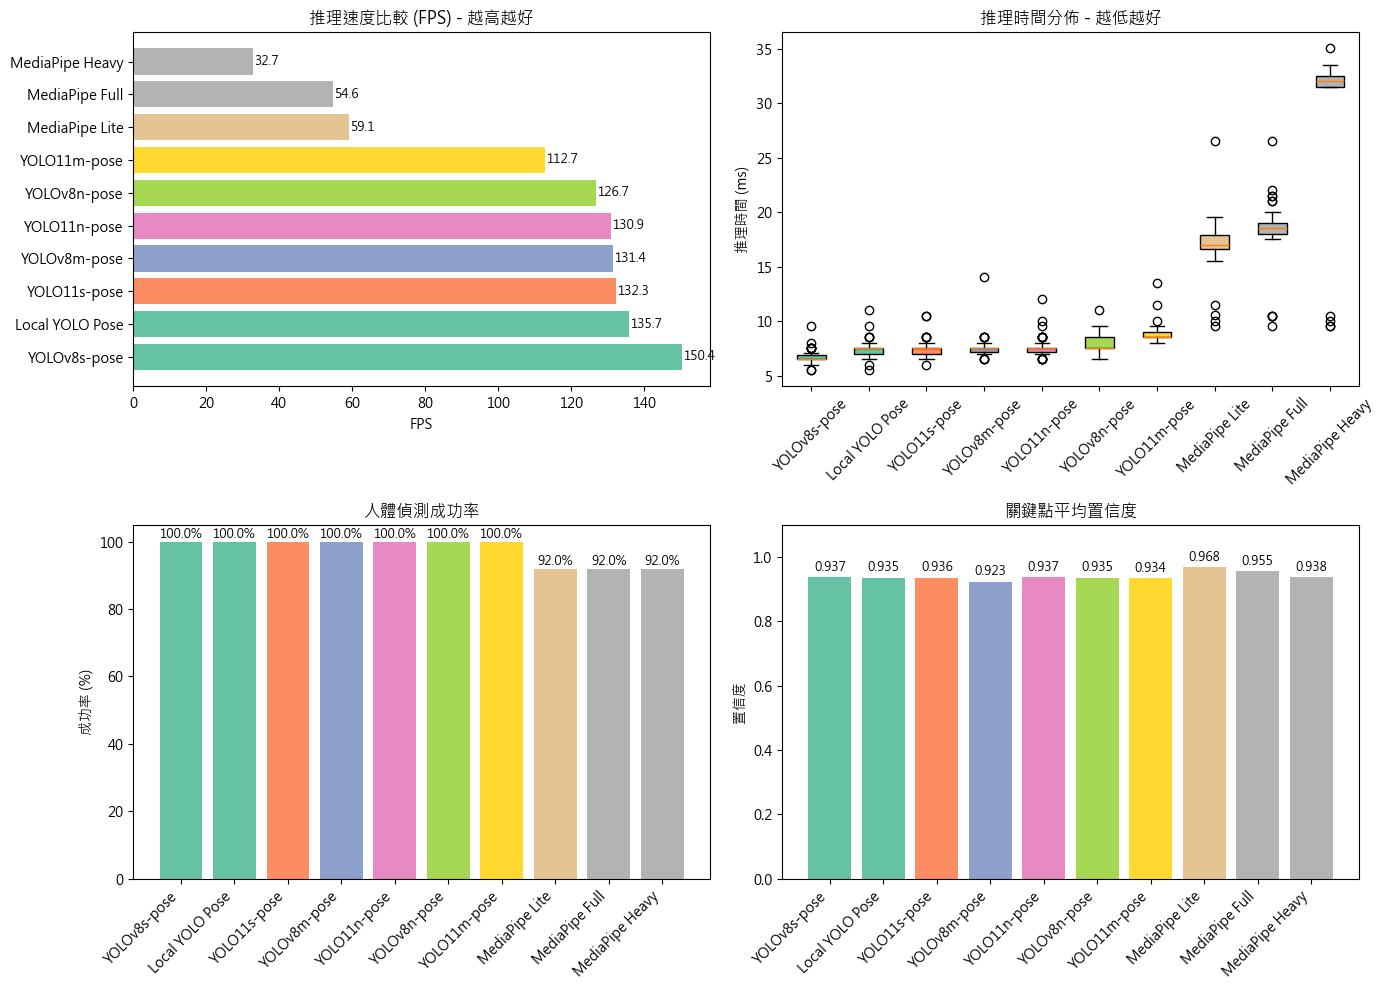


比較圖已儲存至 ./model/pose_model_comparison.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

model_names = results_df['模型'].tolist()
colors = plt.cm.Set2(np.linspace(0, 1, len(model_names)))

# 1. FPS 比較
ax1 = axes[0, 0]
fps_values = results_df['FPS'].tolist()
bars1 = ax1.barh(range(len(model_names)), fps_values, color=colors)
ax1.set_yticks(range(len(model_names)))
ax1.set_yticklabels(model_names)
ax1.set_xlabel('FPS')
ax1.set_title('推理速度比較 (FPS) - 越高越好')
for i, (bar, fps) in enumerate(zip(bars1, fps_values)):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{fps:.1f}', va='center', fontsize=9)

# 2. 推理時間分佈
ax2 = axes[0, 1]
inference_data = [benchmark_results[name]['inference_times'] for name in model_names]
bp = ax2.boxplot(inference_data, labels=model_names, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax2.set_ylabel('推理時間 (ms)')
ax2.set_title('推理時間分佈 - 越低越好')
ax2.tick_params(axis='x', rotation=45)

# 3. 偵測成功率
ax3 = axes[1, 0]
detection_rates = results_df['偵測成功率(%)'].tolist()
bars3 = ax3.bar(range(len(model_names)), detection_rates, color=colors)
ax3.set_xticks(range(len(model_names)))
ax3.set_xticklabels(model_names, rotation=45, ha='right')
ax3.set_ylabel('成功率 (%)')
ax3.set_title('人體偵測成功率')
ax3.set_ylim(0, 105)
for bar, rate in zip(bars3, detection_rates):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{rate:.1f}%', ha='center', fontsize=9)

# 4. 平均置信度
ax4 = axes[1, 1]
confidences = results_df['平均置信度'].tolist()
bars4 = ax4.bar(range(len(model_names)), confidences, color=colors)
ax4.set_xticks(range(len(model_names)))
ax4.set_xticklabels(model_names, rotation=45, ha='right')
ax4.set_ylabel('置信度')
ax4.set_title('關鍵點平均置信度')
ax4.set_ylim(0, 1.1)
for bar, conf in zip(bars4, confidences):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{conf:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('./model/pose_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n比較圖已儲存至 ./model/pose_model_comparison.png")

## 8. 視覺效果比較

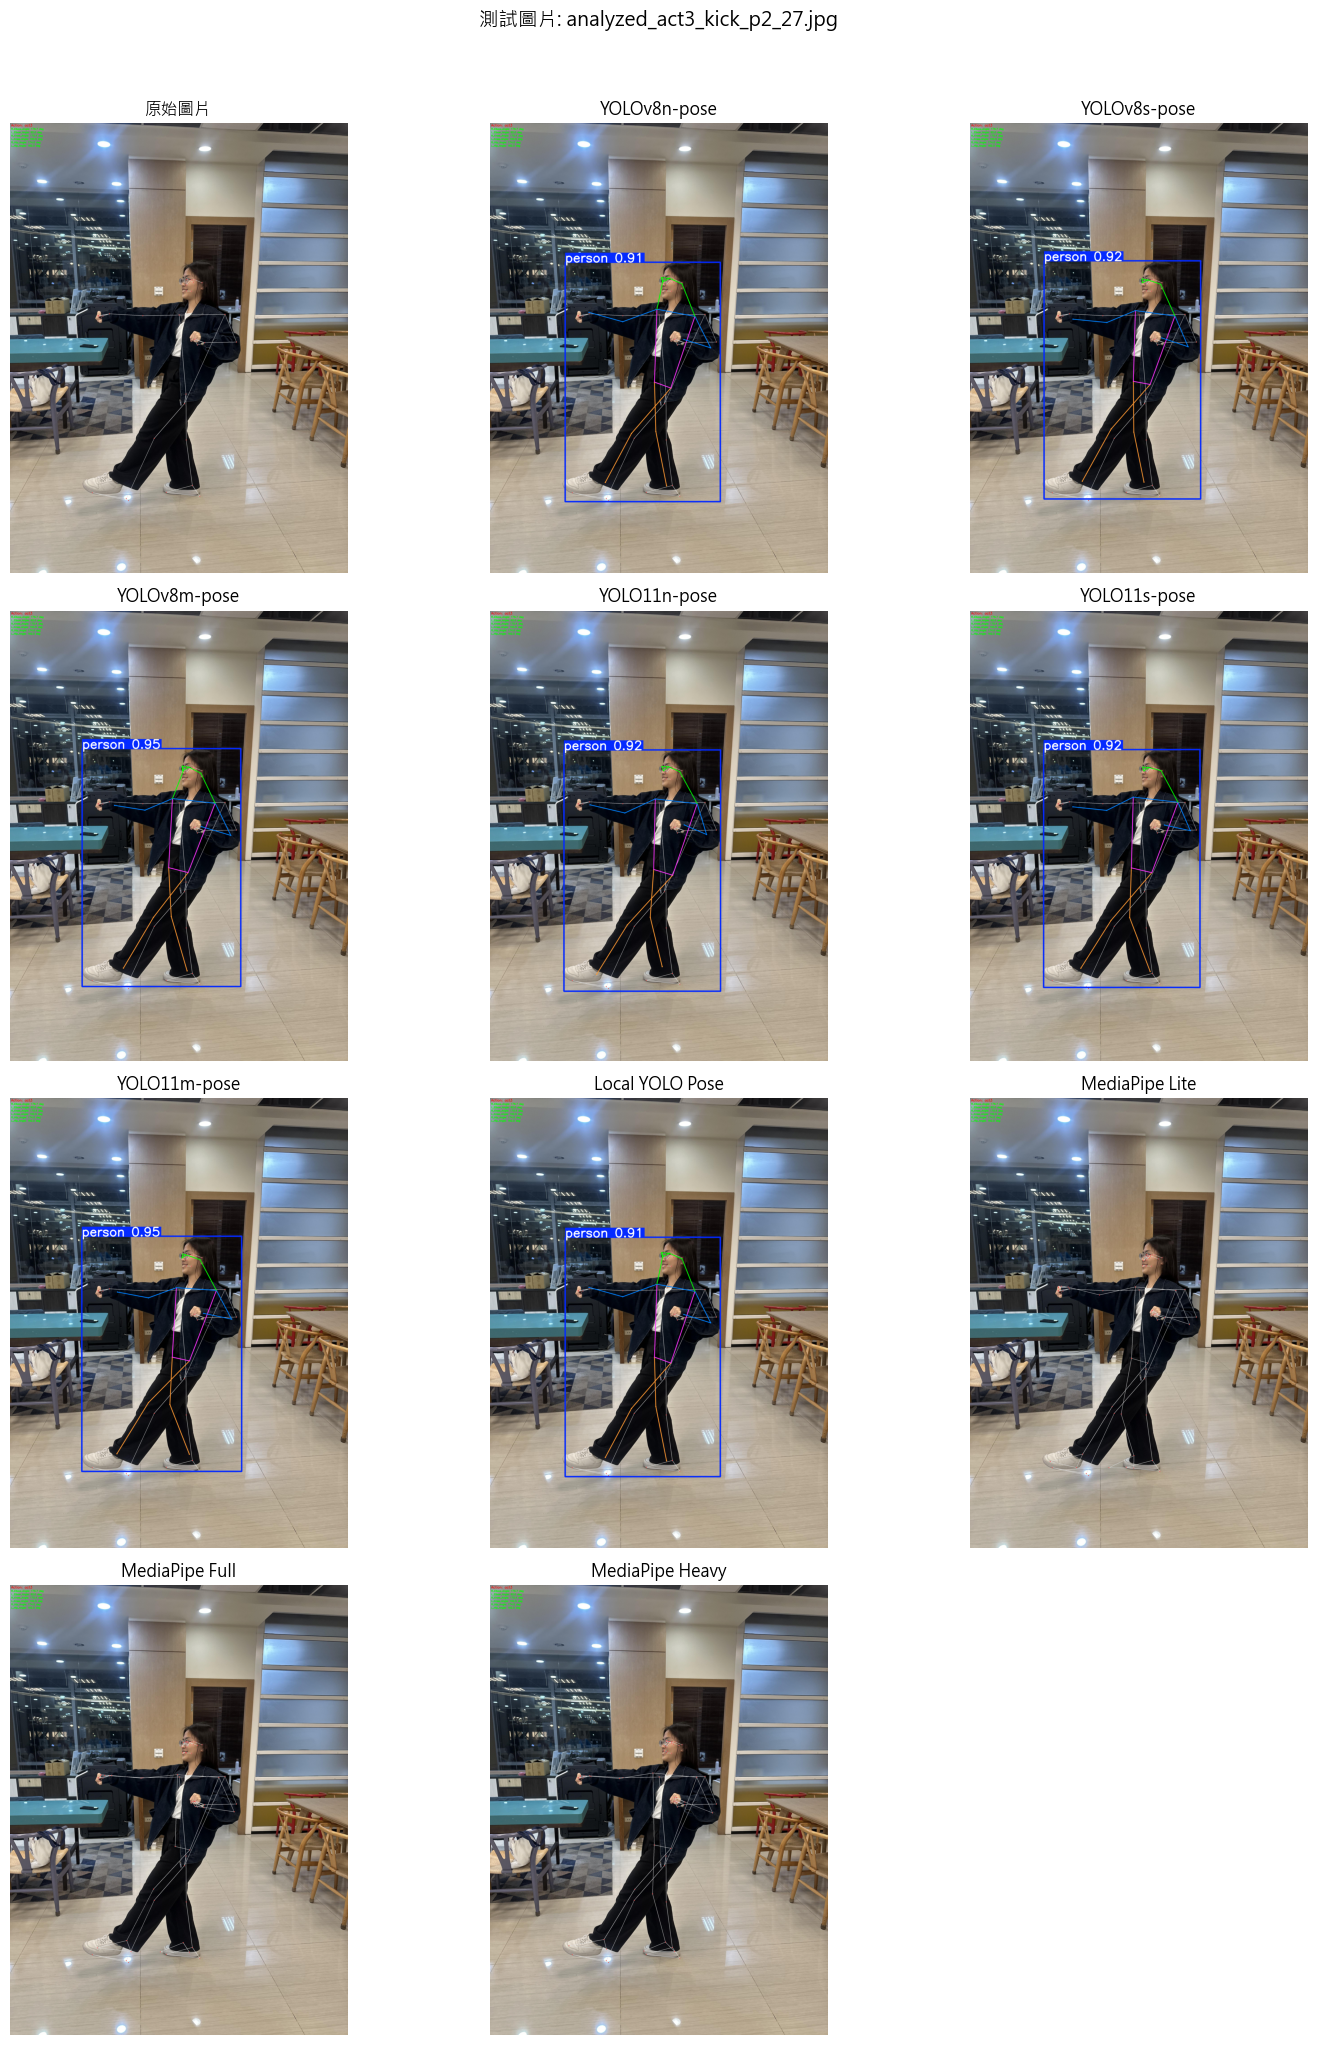


視覺比較圖已儲存至 ./model/pose_visual_comparison.png


In [9]:
# 選擇一張測試圖片展示各模型的視覺效果
sample_image_path = test_images[0]
sample_image = cv2.imread(str(sample_image_path))

n_models = len(models)
n_cols = 3
n_rows = (n_models + n_cols) // n_cols  # +1 for original

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

# 原始圖片
axes[0].imshow(cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB))
axes[0].set_title('原始圖片', fontsize=12)
axes[0].axis('off')

# 各模型的結果
for idx, (name, model) in enumerate(models.items(), 1):
    annotated = model.get_annotated_frame(sample_image)
    axes[idx].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(name, fontsize=12)
    axes[idx].axis('off')

# 隱藏多餘的子圖
for idx in range(len(models) + 1, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(f'測試圖片: {sample_image_path.name}', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('./model/pose_visual_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n視覺比較圖已儲存至 ./model/pose_visual_comparison.png")

## 9. 關鍵點穩定性分析

分析關鍵點穩定性...


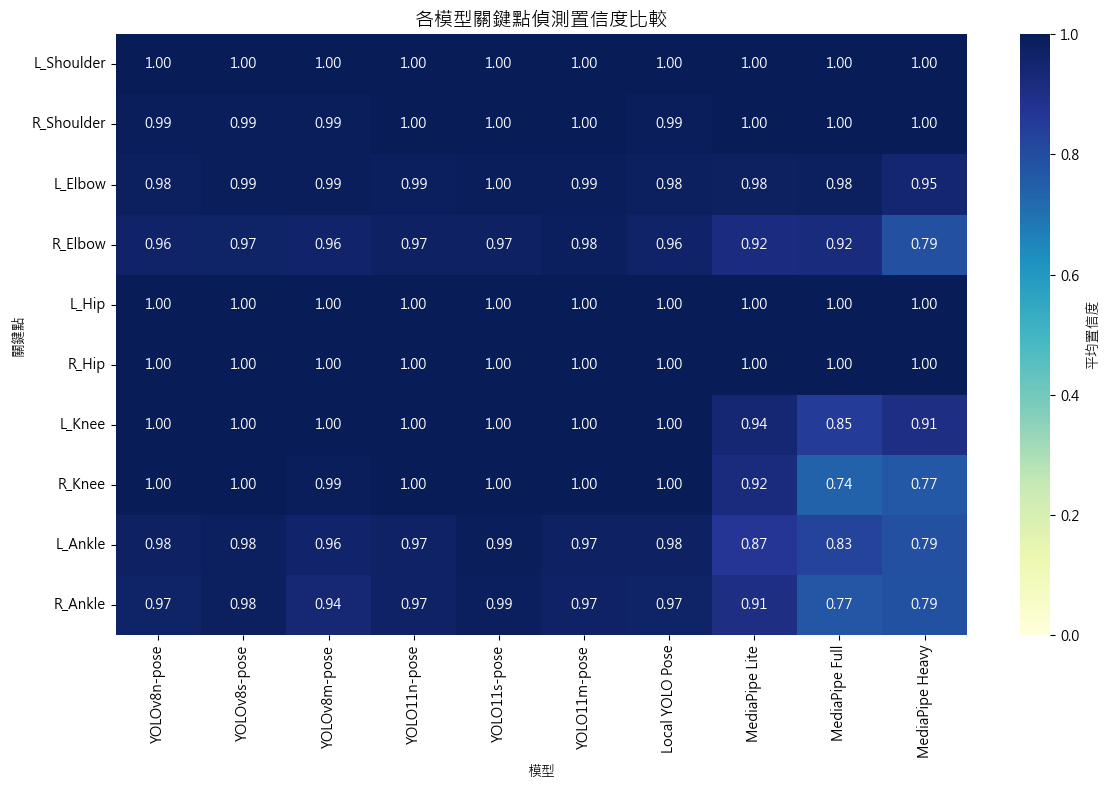


關鍵點置信度熱力圖已儲存至 ./model/keypoint_confidence_heatmap.png


In [10]:
# 分析特定關鍵點的偵測穩定性
# 重要關鍵點索引 (用於功夫動作辨識)
important_keypoints = {
    5: 'L_Shoulder',
    6: 'R_Shoulder', 
    7: 'L_Elbow',
    8: 'R_Elbow',
    11: 'L_Hip',
    12: 'R_Hip',
    13: 'L_Knee',
    14: 'R_Knee',
    15: 'L_Ankle',
    16: 'R_Ankle'
}

keypoint_stats = {name: {kp: [] for kp in important_keypoints.values()} for name in models}

print("分析關鍵點穩定性...")

for img_path in test_images[:30]:  # 使用前 30 張圖片
    image = cv2.imread(str(img_path))
    if image is None:
        continue
    
    for name, model in models.items():
        keypoints, confidences, _ = model.predict(image)
        
        if confidences is not None:
            for idx, kp_name in important_keypoints.items():
                keypoint_stats[name][kp_name].append(confidences[idx])

# 計算平均置信度
keypoint_avg = {}
for name in models:
    keypoint_avg[name] = {}
    for kp_name in important_keypoints.values():
        values = keypoint_stats[name][kp_name]
        keypoint_avg[name][kp_name] = np.mean(values) if values else 0

# 繪製熱力圖
kp_df = pd.DataFrame(keypoint_avg)

plt.figure(figsize=(12, 8))
sns.heatmap(kp_df, annot=True, fmt='.2f', cmap='YlGnBu', 
            vmin=0, vmax=1, cbar_kws={'label': '平均置信度'})
plt.title('各模型關鍵點偵測置信度比較', fontsize=14)
plt.xlabel('模型')
plt.ylabel('關鍵點')
plt.tight_layout()
plt.savefig('./model/keypoint_confidence_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n關鍵點置信度熱力圖已儲存至 ./model/keypoint_confidence_heatmap.png")

## 10. 速度 vs 精度分析

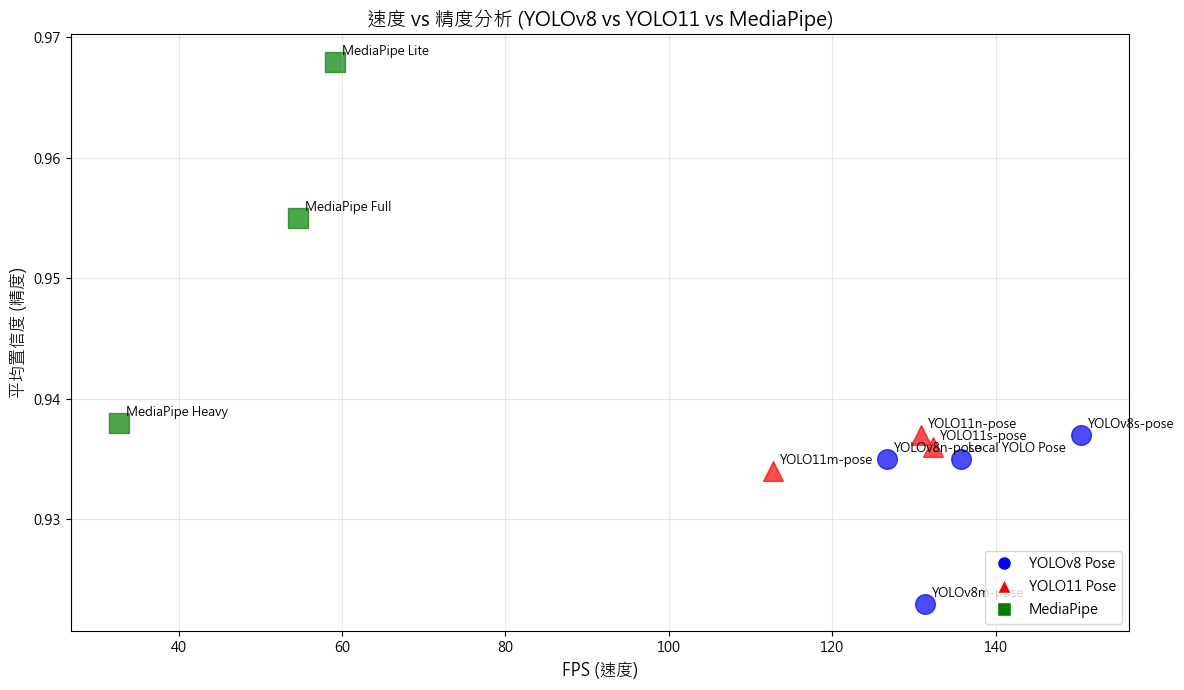


速度vs精度圖已儲存至 ./model/speed_vs_accuracy.png


In [11]:
fig, ax = plt.subplots(figsize=(12, 7))

for i, row in results_df.iterrows():
    name = row['模型']
    fps = row['FPS']
    conf = row['平均置信度']
    
    # 根據模型類型設定顏色和標記
    if 'YOLO11' in name:
        color = 'red'
        marker = '^'
    elif 'YOLO' in name:
        color = 'blue'
        marker = 'o'
    else:
        color = 'green'
        marker = 's'
    
    ax.scatter(fps, conf, s=200, c=color, marker=marker, alpha=0.7, label=name)
    ax.annotate(name, (fps, conf), textcoords="offset points", 
                xytext=(5, 5), fontsize=9)

ax.set_xlabel('FPS (速度)', fontsize=12)
ax.set_ylabel('平均置信度 (精度)', fontsize=12)
ax.set_title('速度 vs 精度分析 (YOLOv8 vs YOLO11 vs MediaPipe)', fontsize=14)
ax.grid(True, alpha=0.3)

# 添加圖例
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='YOLOv8 Pose'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='red', markersize=10, label='YOLO11 Pose'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='green', markersize=10, label='MediaPipe')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('./model/speed_vs_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n速度vs精度圖已儲存至 ./model/speed_vs_accuracy.png")

## 11. 結論與建議

In [12]:
# 找出各項最佳
fastest = results_df.loc[results_df['FPS'].idxmax()]
highest_detection = results_df.loc[results_df['偵測成功率(%)'].idxmax()]
highest_conf = results_df.loc[results_df['平均置信度'].idxmax()]

# 分別找出 YOLOv8 和 YOLO11 最佳
yolov8_df = results_df[results_df['模型'].str.contains('YOLOv8')]
yolo11_df = results_df[results_df['模型'].str.contains('YOLO11')]

print("\n" + "=" * 70)
print("結論與建議")
print("=" * 70)

print(f"\n🏆 整體最佳表現:")
print(f"   最快速度: {fastest['模型']} ({fastest['FPS']:.1f} FPS)")
print(f"   最高偵測率: {highest_detection['模型']} ({highest_detection['偵測成功率(%)']}%)")
print(f"   最高置信度: {highest_conf['模型']} ({highest_conf['平均置信度']:.3f})")

print("\n" + "-" * 70)
print("📊 YOLOv8 vs YOLO11 比較:")
print("-" * 70)

if not yolov8_df.empty and not yolo11_df.empty:
    v8_best = yolov8_df.loc[yolov8_df['FPS'].idxmax()]
    v11_best = yolo11_df.loc[yolo11_df['FPS'].idxmax()]
    
    print(f"\n  YOLOv8 最快: {v8_best['模型']}")
    print(f"    FPS: {v8_best['FPS']:.1f}, 置信度: {v8_best['平均置信度']:.3f}")
    
    print(f"\n  YOLO11 最快: {v11_best['模型']}")
    print(f"    FPS: {v11_best['FPS']:.1f}, 置信度: {v11_best['平均置信度']:.3f}")
    
    # 計算改進幅度
    fps_diff = ((v11_best['FPS'] - v8_best['FPS']) / v8_best['FPS']) * 100
    conf_diff = ((v11_best['平均置信度'] - v8_best['平均置信度']) / v8_best['平均置信度']) * 100
    
    print(f"\n  📈 YOLO11 vs YOLOv8 (同等級比較):")
    print(f"    速度變化: {fps_diff:+.1f}%")
    print(f"    置信度變化: {conf_diff:+.1f}%")

print("\n" + "-" * 70)
print("💡 使用建議:")
print("-" * 70)

print("\n  📱 即時應用 (需要高 FPS):")
print(f"     推薦: YOLO11n-pose 或 YOLOv8n-pose")

print("\n  🎬 離線處理 (追求精度):")
print(f"     推薦: YOLO11m-pose 或 YOLOv8m-pose")

print("\n  ⚖️ 平衡方案:")
print(f"     推薦: YOLO11s-pose 或 YOLOv8s-pose")

print("\n  🔄 升級建議:")
print(f"     如果目前使用 YOLOv8，可考慮升級至 YOLO11 獲得更好性能")

print("\n" + "=" * 70)


結論與建議

🏆 整體最佳表現:
   最快速度: YOLOv8s-pose (150.4 FPS)
   最高偵測率: YOLOv8s-pose (100.0%)
   最高置信度: MediaPipe Lite (0.968)

----------------------------------------------------------------------
📊 YOLOv8 vs YOLO11 比較:
----------------------------------------------------------------------

  YOLOv8 最快: YOLOv8s-pose
    FPS: 150.4, 置信度: 0.937

  YOLO11 最快: YOLO11s-pose
    FPS: 132.3, 置信度: 0.936

  📈 YOLO11 vs YOLOv8 (同等級比較):
    速度變化: -12.0%
    置信度變化: -0.1%

----------------------------------------------------------------------
💡 使用建議:
----------------------------------------------------------------------

  📱 即時應用 (需要高 FPS):
     推薦: YOLO11n-pose 或 YOLOv8n-pose

  🎬 離線處理 (追求精度):
     推薦: YOLO11m-pose 或 YOLOv8m-pose

  ⚖️ 平衡方案:
     推薦: YOLO11s-pose 或 YOLOv8s-pose

  🔄 升級建議:
     如果目前使用 YOLOv8，可考慮升級至 YOLO11 獲得更好性能



In [13]:
# 儲存結果
results_df.to_csv('./model/pose_model_comparison_results.csv', index=False, encoding='utf-8-sig')
print("\n結果已儲存至 ./model/pose_model_comparison_results.csv")

# 清理 MediaPipe 資源
for name, model in models.items():
    if isinstance(model, MediaPipePoseModel):
        model.close()

print("\n測試完成！")


結果已儲存至 ./model/pose_model_comparison_results.csv

測試完成！


## 12. 總結

### 測試的模型

| 類別 | 版本 | 模型 | 關鍵點數量 |
|------|------|------|------------|
| YOLO | v8 | YOLOv8n/s/m-pose | 17 |
| YOLO | v11 | YOLO11n/s/m-pose | 17 |
| MediaPipe | - | Lite/Full/Heavy | 33 (轉換為17) |

### YOLOv8 vs YOLO11

| 特性 | YOLOv8 | YOLO11 |
|------|--------|--------|
| 發布時間 | 2023.01 | 2024.10 |
| 架構 | CSPDarknet | 改進的 backbone |
| Pose 支援 | 成熟穩定 | 最新優化 |

### 輸出檔案

- `model/pose_model_comparison.png` - 整體比較圖
- `model/pose_visual_comparison.png` - 視覺效果對比
- `model/keypoint_confidence_heatmap.png` - 關鍵點置信度熱力圖
- `model/speed_vs_accuracy.png` - 速度vs精度圖
- `model/pose_model_comparison_results.csv` - 結果數據表